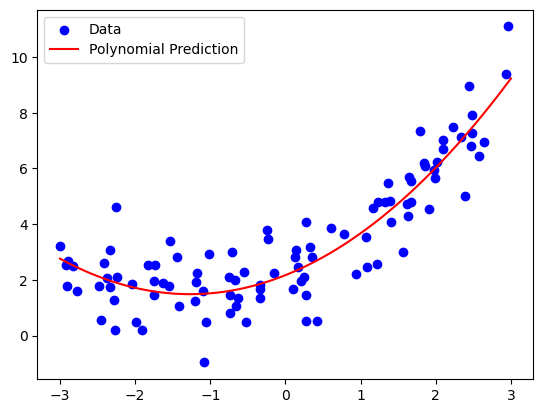

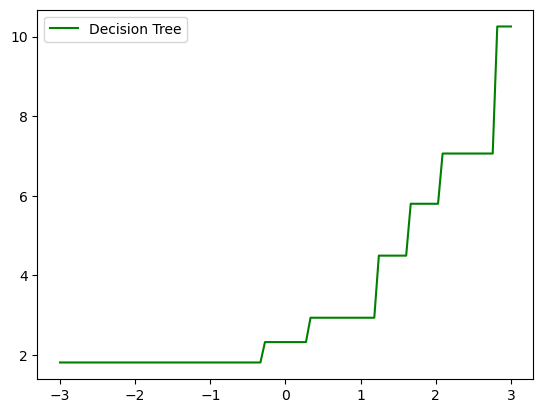

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# 1. Generate "Curvy" Synthetic Data
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)
# 2. Transform X to include X-squared
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
# 3. Fit Linear Regression to the "Squared" data
model = LinearRegression()
model.fit(X_poly, y)
# 4. Plotting the result
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = model.predict(X_new_poly)
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X_new, y_new, color='red', label='Polynomial Prediction')
plt.legend()
plt.show()

# Train a Decision Tree
tree_reg = DecisionTreeRegressor(max_depth=3)
tree_reg.fit(X, y)
# Predict and see how it differs from the curve
y_tree_pred = tree_reg.predict(X_new)
plt.plot(X_new, y_tree_pred, color='green', label='Decision Tree')
plt.legend()
plt.show()


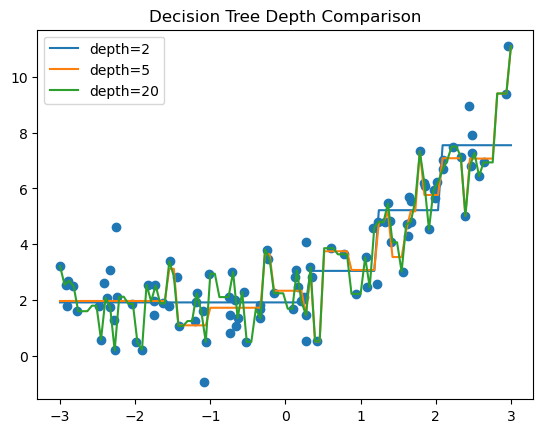

In [2]:
depths = [2, 5, 20]

plt.scatter(X, y)

for d in depths:
    tree = DecisionTreeRegressor(max_depth=d)
    tree.fit(X, y)
    y_pred = tree.predict(X_new)
    plt.plot(X_new, y_pred, label=f"depth={d}")

plt.legend()
plt.title("Decision Tree Depth Comparison")
plt.show()

## Reflection

A “jittery” model that fits all the training data perfectly is a bad model, since it is overfitting the data.
This means the model has learned to “memorize” the training data rather than learn the overall pattern. The outcome of this is poor performance on data not seen before.
A “curvy” model that can pick up an overall pattern in the data while ignoring the noise in the data is a better choice.
Thus, simpler models are favored over complex ones.

In [3]:
from sklearn.metrics import r2_score

# Polynomial Model R2
y_poly_pred = model.predict(X_poly)
r2_poly = r2_score(y, y_poly_pred)

# Decision Tree R2
tree = DecisionTreeRegressor(max_depth=3)
tree.fit(X, y)
y_tree_pred = tree.predict(X)
r2_tree = r2_score(y, y_tree_pred)

print("Polynomial R2:", r2_poly)
print("Decision Tree R2:", r2_tree)

Polynomial R2: 0.8105601639926119
Decision Tree R2: 0.83822479583347
